# BiLSTM Thesis Experiment Notebook

This notebook trains and evaluates a **character-level BiLSTM sequence-to-sequence model with attention** for Mauritian Creole text restoration:

- Orthographic text normalization
- Punctuation restoration
- Capitalization restoration

It keeps the **same metrics and comparison graphs** as the ByT5 and T5 notebooks so that the final comparison across **ByT5, T5, Qwen, and BiLSTM** is consistent.

The notebook saves:

- Training time
- Inference time
- Train / validation / test metrics
- Overfitting plots
- Predictions
- Error analysis
- BiLSTM-specific character vocabulary and OOV analysis
- Sequence length, padding, and truncation analysis
- Parameter count and gradient norm tracking
- Orthographic variation recovery analysis
- Emoji/symbol subset analysis
- Synthetic noise robustness analysis

## 1. Install libraries

Run this once on RunPod if needed.

In [6]:
# Uncomment this cell on RunPod if needed.
# %pip install -U torch pandas numpy matplotlib sacrebleu jiwer scikit-learn tqdm

## 2. Imports

In [39]:
import os
import re
import json
import time
import math
import random
import platform
import warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any, Tuple
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from jiwer import wer, cer
from sacrebleu.metrics import CHRF
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

## 3. Configuration

Edit the file paths and column names before running.

In [8]:
EXPERIMENT_NAME = "bilstm_mauritian_creole_text_restoration"
MODEL_NAME = "char_bilstm_seq2seq_attention"

# Paths to train-val-test data
TRAIN_PATH = "/workspace/mauritian_creole_nlp/data/dataset_split/train.json"
VAL_PATH   = "/workspace/mauritian_creole_nlp/data/dataset_split/val.json"
TEST_PATH  = "/workspace/mauritian_creole_nlp/data/dataset_split/test.json"

# Columns in JSON files
INPUT_COL = "text"
TARGET_COL = "standardized"

OUTPUT_DIR = Path("results") / "bilstm"
for sub in ["plots", "predictions", "analysis", "checkpoints"]:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

SEED = 18
MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 256

# BiLSTM architecture settings
EMBEDDING_DIM = 128
ENCODER_HIDDEN_SIZE = 256
DECODER_HIDDEN_SIZE = 256
NUM_ENCODER_LAYERS = 1
DROPOUT = 0.3

# Training settings
NUM_EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
CLIP_GRAD_NORM = 1.0
TEACHER_FORCING_RATIO = 0.5
PATIENCE = 7

# Evaluation settings
EVAL_SAMPLE_LIMIT = None  # Set to 500 for quick testing; use None for full thesis run.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed = lambda seed: (random.seed(seed), np.random.seed(seed), torch.manual_seed(seed), torch.cuda.manual_seed_all(seed) if torch.cuda.is_available() else None)
set_seed(SEED)

(None, None, <torch._C.Generator at 0x7ecd79b19c70>, None)

## 4. Environment and GPU information

In [9]:
def get_environment_info() -> Dict[str, Any]:
    info = {
        "experiment_name": EXPERIMENT_NAME,
        "timestamp": datetime.now().isoformat(),
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "pytorch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "model_name": MODEL_NAME,
        "seed": SEED,
        "device": str(DEVICE),
        "embedding_dim": EMBEDDING_DIM,
        "encoder_hidden_size": ENCODER_HIDDEN_SIZE,
        "decoder_hidden_size": DECODER_HIDDEN_SIZE,
        "num_encoder_layers": NUM_ENCODER_LAYERS,
        "dropout": DROPOUT,
        "teacher_forcing_ratio": TEACHER_FORCING_RATIO,
    }
    if torch.cuda.is_available():
        info.update({
            "gpu_name": torch.cuda.get_device_name(0),
            "gpu_count": torch.cuda.device_count(),
            "gpu_capability": str(torch.cuda.get_device_capability(0)),
        })
    return info

env_info = get_environment_info()
print(json.dumps(env_info, indent=2))
with open(OUTPUT_DIR / "environment_info.json", "w", encoding="utf-8") as f:
    json.dump(env_info, f, indent=2, ensure_ascii=False)

{
  "experiment_name": "bilstm_mauritian_creole_text_restoration",
  "timestamp": "2026-08-04T12:42:06.577109",
  "python_version": "3.12.3",
  "platform": "Linux-6.8.0-124-generic-x86_64-with-glibc2.39",
  "pytorch_version": "2.8.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "model_name": "char_bilstm_seq2seq_attention",
  "seed": 18,
  "device": "cuda",
  "embedding_dim": 128,
  "encoder_hidden_size": 256,
  "decoder_hidden_size": 256,
  "num_encoder_layers": 1,
  "dropout": 0.3,
  "teacher_forcing_ratio": 0.5,
  "gpu_name": "NVIDIA GeForce RTX 4090",
  "gpu_count": 1,
  "gpu_capability": "(8, 9)"
}


## 5. Load train, validation, and test data

In [10]:
def load_json(path: str, split_name: str) -> pd.DataFrame:
    path_obj = Path(path)

    if not path_obj.exists():
        raise FileNotFoundError(
            f"Missing {split_name} file: {path}. Update the path in the configuration cell."
        )

    df = pd.read_json(path_obj)

    if INPUT_COL not in df.columns or TARGET_COL not in df.columns:
        raise ValueError(
            f"{split_name} must contain '{INPUT_COL}' and '{TARGET_COL}'. "
            f"Found: {list(df.columns)}"
        )

    df = df[[INPUT_COL, TARGET_COL]].copy()

    df[INPUT_COL] = df[INPUT_COL].fillna("").astype(str)
    df[TARGET_COL] = df[TARGET_COL].fillna("").astype(str)

    df = df[
        (df[INPUT_COL].str.strip() != "") &
        (df[TARGET_COL].str.strip() != "")
    ].reset_index(drop=True)

    df["split"] = split_name

    return df


train_df = load_json(TRAIN_PATH, "train")
val_df = load_json(VAL_PATH, "val")
test_df = load_json(TEST_PATH, "test")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_df.head())

Train: (11064, 3)
Validation: (1383, 3)
Test: (1383, 3)


,text,standardized,split
0,La dan zenfant ki victime femme bizin pran con...,Ladan zanfan ki victime femme bizin pran kont ...,train
1,Or believe li couyoun li kit so parliamentary ...,Or believe li kuyon. Li kite so parliamentary ...,train
2,Apres zot dire ena soldat dan moris. Mo sire v...,Apre zot dire ena soldat dan Moris. Mo sir vac...,train
3,Et voilà c’est reparti avec bann intellectuel ...,Et voilà. Se reparti avec bann intellectuel fa...,train
4,Wadir dan film,Wadire dan film.,train


## 6. Dataset statistics

In [11]:
def basic_text_stats(df: pd.DataFrame, text_col: str, split_name: str) -> Dict[str, Any]:
    texts = df[text_col].astype(str).tolist()
    words = [w for t in texts for w in t.split()]
    chars = [ch for t in texts for ch in t]
    return {
        "split": split_name,
        "column": text_col,
        "num_rows": len(df),
        "num_words": len(words),
        "word_vocab_size": len(set(words)),
        "num_characters": len(chars),
        "character_vocab_size": len(set(chars)),
        "avg_words_per_sentence": float(np.mean([len(t.split()) for t in texts])) if texts else 0,
        "avg_chars_per_sentence": float(np.mean([len(t) for t in texts])) if texts else 0,
        "max_chars_sentence": int(max([len(t) for t in texts], default=0)),
    }

stats_rows = []
for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    stats_rows.append(basic_text_stats(df, INPUT_COL, split_name))
    stats_rows.append(basic_text_stats(df, TARGET_COL, split_name))

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(OUTPUT_DIR / "dataset_statistics.csv", index=False, encoding="utf-8")
display(stats_df)

,split,column,num_rows,num_words,word_vocab_size,num_characters,character_vocab_size,avg_words_per_sentence,avg_chars_per_sentence,max_chars_sentence
0,train,text,11064,195282,25124,1000800,392,17.650217,90.455531,1261
1,train,standardized,11064,193408,21436,1012864,366,17.480839,91.545915,1246
2,validation,text,1383,24611,6764,126035,211,17.795372,91.131598,1073
3,validation,standardized,1383,24351,5982,127555,206,17.607375,92.230658,1053
4,test,text,1383,24784,6822,126139,257,17.920463,91.206797,1123
5,test,standardized,1383,24512,6143,127598,249,17.723789,92.261750,1183


## 7. Build character vocabulary

The BiLSTM model is character-level. This makes it suitable for orthographic variation analysis because the model learns from characters rather than subword tokens.

In [12]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

def build_char_vocab(train_df: pd.DataFrame) -> Tuple[Dict[str, int], Dict[int, str]]:
    chars = set()
    for col in [INPUT_COL, TARGET_COL]:
        for text in train_df[col].astype(str).tolist():
            chars.update(list(text))
    sorted_chars = sorted(chars)
    itos = SPECIAL_TOKENS + sorted_chars
    stoi = {ch: i for i, ch in enumerate(itos)}
    return stoi, {i: ch for ch, i in stoi.items()}

stoi, itos = build_char_vocab(train_df)
PAD_IDX = stoi[PAD_TOKEN]
SOS_IDX = stoi[SOS_TOKEN]
EOS_IDX = stoi[EOS_TOKEN]
UNK_IDX = stoi[UNK_TOKEN]
VOCAB_SIZE = len(stoi)

vocab_info = {
    "vocab_size": VOCAB_SIZE,
    "num_special_tokens": len(SPECIAL_TOKENS),
    "pad_idx": PAD_IDX,
    "sos_idx": SOS_IDX,
    "eos_idx": EOS_IDX,
    "unk_idx": UNK_IDX,
}

with open(OUTPUT_DIR / "analysis" / "character_vocab.json", "w", encoding="utf-8") as f:
    json.dump({"stoi": stoi, "itos": itos, "vocab_info": vocab_info}, f, indent=2, ensure_ascii=False)

print(json.dumps(vocab_info, indent=2))

{
  "vocab_size": 397,
  "num_special_tokens": 4,
  "pad_idx": 0,
  "sos_idx": 1,
  "eos_idx": 2,
  "unk_idx": 3
}


## 8. BiLSTM-specific character/OOV analysis

This tracks character coverage, OOV characters in validation/test, sequence lengths, padding, and truncation.

In [13]:
def char_oov_rate(texts: List[str], stoi: Dict[str, int]) -> Dict[str, Any]:
    total_chars = 0
    oov_chars = 0
    unique_oov = Counter()
    for text in texts:
        for ch in str(text):
            total_chars += 1
            if ch not in stoi:
                oov_chars += 1
                unique_oov[ch] += 1
    return {
        "total_chars": total_chars,
        "oov_chars": oov_chars,
        "oov_rate": oov_chars / total_chars if total_chars else 0.0,
        "unique_oov_chars": dict(unique_oov.most_common()),
    }

def add_char_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["input_char_len"] = out[INPUT_COL].apply(lambda x: len(str(x)) + 2)  # SOS/EOS
    out["target_char_len"] = out[TARGET_COL].apply(lambda x: len(str(x)) + 2)
    out["input_truncated"] = out["input_char_len"] > MAX_INPUT_LENGTH
    out["target_truncated"] = out["target_char_len"] > MAX_TARGET_LENGTH
    out["input_padding_needed"] = MAX_INPUT_LENGTH - out["input_char_len"].clip(upper=MAX_INPUT_LENGTH)
    out["target_padding_needed"] = MAX_TARGET_LENGTH - out["target_char_len"].clip(upper=MAX_TARGET_LENGTH)
    return out

char_train = add_char_features(train_df)
char_val = add_char_features(val_df)
char_test = add_char_features(test_df)
char_all = pd.concat([char_train, char_val, char_test], ignore_index=True)

char_summary = char_all.groupby("split")[[
    "input_char_len", "target_char_len", "input_truncated", "target_truncated", "input_padding_needed", "target_padding_needed"
]].agg(["mean", "median", "min", "max"]).round(3)

coverage = {
    "validation_input_oov": char_oov_rate(val_df[INPUT_COL].tolist(), stoi),
    "validation_target_oov": char_oov_rate(val_df[TARGET_COL].tolist(), stoi),
    "test_input_oov": char_oov_rate(test_df[INPUT_COL].tolist(), stoi),
    "test_target_oov": char_oov_rate(test_df[TARGET_COL].tolist(), stoi),
}

char_all.to_csv(OUTPUT_DIR / "analysis" / "bilstm_character_features_all_splits.csv", index=False, encoding="utf-8")
char_summary.to_csv(OUTPUT_DIR / "analysis" / "bilstm_character_summary.csv", encoding="utf-8")
with open(OUTPUT_DIR / "analysis" / "bilstm_oov_character_analysis.json", "w", encoding="utf-8") as f:
    json.dump(coverage, f, indent=2, ensure_ascii=False)

display(char_summary)
print(json.dumps(coverage, indent=2, ensure_ascii=False))

input_char_len                  target_char_len                   \
                mean median min   max            mean median min   max   
split                                                                    
test          93.207   64.0   5  1125          94.262   64.0   6  1185   
train         92.456   64.0   5  1263          93.546   65.0   5  1248   
val           93.132   64.0   4  1075          94.231   65.0   5  1055   

      input_truncated         ... target_truncated       input_padding_needed  \
                 mean median  ...              min   max                 mean   
split                         ...                                               
test            0.048    0.0  ...            False  True              170.223   
train           0.052    0.0  ...            False  True              170.538   
val             0.058    0.0  ...            False  True              170.169   

                      target_padding_needed                  
      median min  max                  mean median min  max  
split                                                        
test   192.0   0  251               169.387  192.0   0  250  
train  192.0   0  251               169.571  191.0   0  251  
val    192.0   0  252               169.294  191.0   0  251  

[3 rows x 24 columns]

{
  "validation_input_oov": {
    "total_chars": 126035,
    "oov_chars": 15,
    "oov_rate": 0.00011901455944777245,
    "unique_oov_chars": {
      "🚨": 3,
      "🍗": 2,
      "🇨": 2,
      "🇦": 2,
      "🪦": 1,
      "🎓": 1,
      "💣": 1,
      "🍃": 1,
      "🦅": 1,
      "⁉": 1
    }
  },
  "validation_target_oov": {
    "total_chars": 127555,
    "oov_chars": 15,
    "oov_rate": 0.00011759633099447298,
    "unique_oov_chars": {
      "🚨": 3,
      "🍗": 2,
      "🇨": 2,
      "🇦": 2,
      "🪦": 1,
      "🎓": 1,
      "💣": 1,
      "🍃": 1,
      "🦅": 1,
      "⁉": 1
    }
  },
  "test_input_oov": {
    "total_chars": 126139,
    "oov_chars": 62,
    "oov_rate": 0.0004915212582944212,
    "unique_oov_chars": {
      "𝒏": 5,
      "𝒊": 4,
      "𝒓": 4,
      "🚍": 3,
      "🍺": 3,
      "𝒕": 3,
      "𝒆": 3,
      "𝒂": 3,
      "🚌": 2,
      "♨": 2,
      "󠁧": 2,
      "😋": 2,
      "👊": 1,
      "ĺ": 1,
      "🎓": 1,
      "🥝": 1,
      "😟": 1,
      "👭": 1,
      "🇸": 1,
      "🇬": 1

## 9. Plot character sequence length distribution

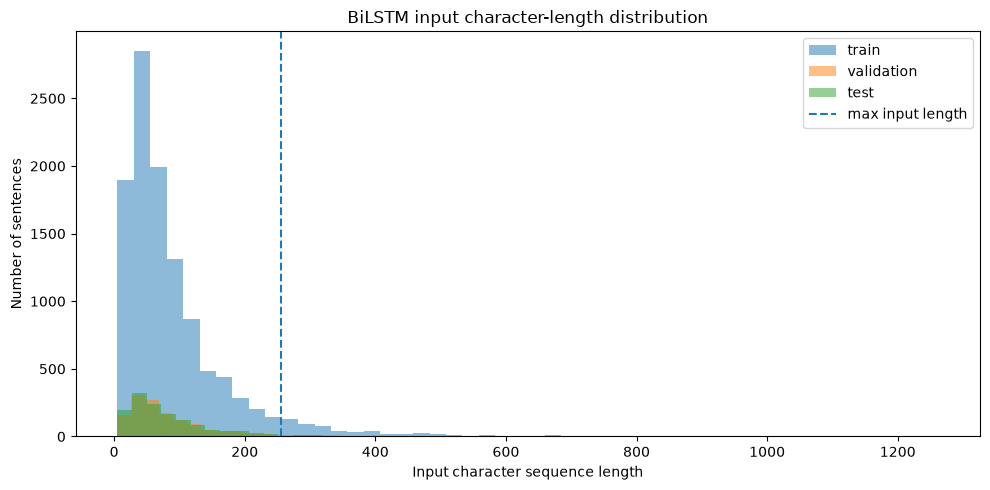

In [14]:
plt.figure(figsize=(10, 5))
for split_name, df in [("train", char_train), ("validation", char_val), ("test", char_test)]:
    plt.hist(df["input_char_len"], bins=50, alpha=0.5, label=split_name)
plt.axvline(MAX_INPUT_LENGTH, linestyle="--", label="max input length")
plt.xlabel("Input character sequence length")
plt.ylabel("Number of sentences")
plt.title("BiLSTM input character-length distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "bilstm_input_character_length_distribution.png", dpi=200)
plt.show()

## 10. Encoding and decoding functions

In [15]:
def encode_text(text: str, max_len: int) -> List[int]:
    ids = [SOS_IDX]
    ids.extend([stoi.get(ch, UNK_IDX) for ch in str(text)])
    ids.append(EOS_IDX)
    ids = ids[:max_len]
    if ids[-1] != EOS_IDX:
        ids[-1] = EOS_IDX
    return ids

def decode_ids(ids: List[int]) -> str:
    chars = []
    for idx in ids:
        if idx == EOS_IDX:
            break
        if idx in [PAD_IDX, SOS_IDX]:
            continue
        chars.append(itos.get(int(idx), ""))
    return "".join(chars)

example = train_df.iloc[0][INPUT_COL]
encoded_example = encode_text(example, MAX_INPUT_LENGTH)
print("Raw:", example)
print("Encoded:", encoded_example[:50])
print("Decoded:", decode_ids(encoded_example))

Raw: La dan zenfant ki victime femme bizin pran contre pas laisse zote peige'
Encoded: [1, 47, 65, 4, 68, 65, 78, 4, 90, 69, 78, 70, 65, 78, 84, 4, 75, 73, 4, 86, 73, 67, 84, 73, 77, 69, 4, 70, 69, 77, 77, 69, 4, 66, 73, 90, 73, 78, 4, 80, 82, 65, 78, 4, 67, 79, 78, 84, 82, 69]
Decoded: La dan zenfant ki victime femme bizin pran contre pas laisse zote peige'


## 11. Dataset and DataLoader

In [16]:
class CharSeq2SeqDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.inputs = df[INPUT_COL].astype(str).tolist()
        self.targets = df[TARGET_COL].astype(str).tolist()

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        src = encode_text(self.inputs[idx], MAX_INPUT_LENGTH)
        tgt = encode_text(self.targets[idx], MAX_TARGET_LENGTH)
        return {
            "src": torch.tensor(src, dtype=torch.long),
            "tgt": torch.tensor(tgt, dtype=torch.long),
            "input_text": self.inputs[idx],
            "target_text": self.targets[idx],
        }

def collate_batch(batch):
    src_lengths = torch.tensor([len(item["src"]) for item in batch], dtype=torch.long)
    tgt_lengths = torch.tensor([len(item["tgt"]) for item in batch], dtype=torch.long)
    max_src = max(src_lengths).item()
    max_tgt = max(tgt_lengths).item()
    src_batch = torch.full((len(batch), max_src), PAD_IDX, dtype=torch.long)
    tgt_batch = torch.full((len(batch), max_tgt), PAD_IDX, dtype=torch.long)
    input_texts, target_texts = [], []
    for i, item in enumerate(batch):
        src_batch[i, :len(item["src"])] = item["src"]
        tgt_batch[i, :len(item["tgt"])] = item["tgt"]
        input_texts.append(item["input_text"])
        target_texts.append(item["target_text"])
    return {
        "src": src_batch,
        "tgt": tgt_batch,
        "src_lengths": src_lengths,
        "tgt_lengths": tgt_lengths,
        "input_texts": input_texts,
        "target_texts": target_texts,
    }

train_loader = DataLoader(CharSeq2SeqDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(CharSeq2SeqDataset(val_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(CharSeq2SeqDataset(test_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

batch = next(iter(train_loader))
print(batch["src"].shape, batch["tgt"].shape)

torch.Size([64, 256]) torch.Size([64, 256])


## 12. BiLSTM encoder-decoder with attention

In [17]:
class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.hidden_bridge = nn.Linear(hidden_size * 2, DECODER_HIDDEN_SIZE)
        self.cell_bridge = nn.Linear(hidden_size * 2, DECODER_HIDDEN_SIZE)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, (hidden, cell) = self.lstm(packed_embedded)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs, batch_first=True, total_length=src.size(1)
        )
        hidden_cat = torch.cat([hidden[-2], hidden[-1]], dim=1)
        cell_cat = torch.cat([cell[-2], cell[-1]], dim=1)
        decoder_hidden = torch.tanh(self.hidden_bridge(hidden_cat))
        decoder_cell = torch.tanh(self.cell_bridge(cell_cat))
        return outputs, decoder_hidden, decoder_cell


class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, encoder_hidden_size, decoder_hidden_size, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.attn = nn.Linear((encoder_hidden_size * 2) + decoder_hidden_size, decoder_hidden_size)
        self.v = nn.Linear(decoder_hidden_size, 1, bias=False)
        self.lstm_cell = nn.LSTMCell(embedding_dim + encoder_hidden_size * 2, decoder_hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(decoder_hidden_size + encoder_hidden_size * 2 + embedding_dim, vocab_size)

    def compute_attention(self, hidden, encoder_outputs, src_mask):
        src_len = encoder_outputs.size(1)
        hidden_expanded = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat([hidden_expanded, encoder_outputs], dim=2)))
        scores = self.v(energy).squeeze(2)
        scores = scores.masked_fill(~src_mask, -1e9)
        attn_weights = F.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights

    def forward_step(self, input_token, hidden, cell, encoder_outputs, src_mask):
        embedded = self.dropout(self.embedding(input_token))
        context, attn_weights = self.compute_attention(hidden, encoder_outputs, src_mask)
        hidden, cell = self.lstm_cell(torch.cat([embedded, context], dim=1), (hidden, cell))
        logits = self.fc_out(torch.cat([hidden, context, embedded], dim=1))
        return logits, hidden, cell, attn_weights


class BiLSTMSeq2Seq(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.vocab_size = vocab_size
        self.encoder = BiLSTMEncoder(
            vocab_size, EMBEDDING_DIM, ENCODER_HIDDEN_SIZE, NUM_ENCODER_LAYERS, DROPOUT
        )
        self.decoder = AttentionDecoder(
            vocab_size, EMBEDDING_DIM, ENCODER_HIDDEN_SIZE, DECODER_HIDDEN_SIZE, DROPOUT
        )

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.size()
        outputs = torch.zeros(batch_size, tgt_len, self.vocab_size, device=src.device)
        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        src_mask = src.ne(PAD_IDX)
        input_token = tgt[:, 0]
        for t in range(1, tgt_len):
            logits, hidden, cell, _ = self.decoder.forward_step(
                input_token, hidden, cell, encoder_outputs, src_mask
            )
            outputs[:, t, :] = logits
            top1 = logits.argmax(dim=1)
            input_token = tgt[:, t] if random.random() < teacher_forcing_ratio else top1
        return outputs

    @torch.no_grad()
    def greedy_decode(self, src, src_lengths, max_len=MAX_TARGET_LENGTH, return_attention=False):
        self.eval()
        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        src_mask = src.ne(PAD_IDX)
        batch_size = src.size(0)
        input_token = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)
        decoded, attentions = [], []
        finished = torch.zeros(batch_size, dtype=torch.bool, device=src.device)

        for _ in range(max_len - 1):
            logits, hidden, cell, attn_weights = self.decoder.forward_step(
                input_token, hidden, cell, encoder_outputs, src_mask
            )
            next_token = logits.argmax(dim=1)
            next_token = torch.where(finished, torch.full_like(next_token, EOS_IDX), next_token)
            decoded.append(next_token.unsqueeze(1))
            if return_attention:
                attentions.append(attn_weights.detach().cpu())
            finished = finished | next_token.eq(EOS_IDX)
            input_token = next_token
            if finished.all():
                break

        decoded = torch.cat(decoded, dim=1) if decoded else torch.empty(
            batch_size, 0, dtype=torch.long, device=src.device
        )
        return (decoded, attentions) if return_attention else decoded


# The model is created in the same cell as the class definitions.
model = BiLSTMSeq2Seq(VOCAB_SIZE).to(DEVICE)
print("Model created successfully:", type(model).__name__)


Model created successfully: BiLSTMSeq2Seq


## 13. BiLSTM-specific model size and parameter count

In [18]:
def count_parameters(model: nn.Module) -> Dict[str, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total_parameters": total, "trainable_parameters": trainable}

if "model" not in globals():
    raise RuntimeError("Run Section 12 first. Section 12 defines BiLSTMSeq2Seq and creates model.")

parameter_info = count_parameters(model)
with open(OUTPUT_DIR / "analysis" / "bilstm_parameter_count.json", "w", encoding="utf-8") as f:
    json.dump(parameter_info, f, indent=2, ensure_ascii=False)
print(json.dumps(parameter_info, indent=2))


{
  "total_parameters": 2627597,
  "trainable_parameters": 2627597
}


## 14. Metric functions

These match the ByT5 and T5 notebooks for fair comparison.

In [19]:
chrf_metric = CHRF(word_order=2)
PUNCTUATION_MARKS = set(list(".,!?;:"))

def normalize_for_metric(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()

def exact_match_score(preds: List[str], refs: List[str]) -> float:
    return float(np.mean([normalize_for_metric(p) == normalize_for_metric(r) for p, r in zip(preds, refs)])) if refs else 0.0

def word_accuracy(preds: List[str], refs: List[str]) -> float:
    total = 0
    correct = 0
    for pred, ref in zip(preds, refs):
        pred_words = normalize_for_metric(pred).split()
        ref_words = normalize_for_metric(ref).split()
        max_len = max(len(pred_words), len(ref_words))
        if max_len == 0:
            continue
        total += max_len
        for i in range(max_len):
            pw = pred_words[i] if i < len(pred_words) else None
            rw = ref_words[i] if i < len(ref_words) else None
            correct += int(pw == rw)
    return correct / total if total else 0.0

def get_punctuation_sequence(text: str) -> List[str]:
    return [ch for ch in str(text) if ch in PUNCTUATION_MARKS]

def punctuation_prf(preds: List[str], refs: List[str]) -> Dict[str, float]:
    y_true, y_pred = [], []
    for pred, ref in zip(preds, refs):
        pred_p = get_punctuation_sequence(pred)
        ref_p = get_punctuation_sequence(ref)
        max_len = max(len(pred_p), len(ref_p))
        for i in range(max_len):
            y_pred.append(pred_p[i] if i < len(pred_p) else "NONE")
            y_true.append(ref_p[i] if i < len(ref_p) else "NONE")
    if not y_true:
        return {"punct_precision": 0.0, "punct_recall": 0.0, "punct_f1": 0.0, "punct_accuracy": 0.0}
    labels = sorted(list(PUNCTUATION_MARKS))
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    return {
        "punct_precision": float(precision),
        "punct_recall": float(recall),
        "punct_f1": float(f1),
        "punct_accuracy": float(accuracy_score(y_true, y_pred)),
    }

def capitalization_labels(text: str) -> List[int]:
    return [1 if ch.isupper() else 0 for ch in str(text) if ch.isalpha()]

def capitalization_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    y_true, y_pred = [], []
    for pred, ref in zip(preds, refs):
        pred_caps = capitalization_labels(pred)
        ref_caps = capitalization_labels(ref)
        max_len = max(len(pred_caps), len(ref_caps))
        for i in range(max_len):
            y_pred.append(pred_caps[i] if i < len(pred_caps) else 0)
            y_true.append(ref_caps[i] if i < len(ref_caps) else 0)
    if not y_true:
        return {"capitalization_accuracy": 0.0, "capitalization_f1": 0.0}
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {"capitalization_accuracy": float(accuracy_score(y_true, y_pred)), "capitalization_f1": float(f1)}

def compute_text_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    preds_norm = [normalize_for_metric(p) for p in preds]
    refs_norm = [normalize_for_metric(r) for r in refs]
    metrics = {
        "cer": float(cer(refs_norm, preds_norm)),
        "wer": float(wer(refs_norm, preds_norm)),
        "chrf": float(chrf_metric.corpus_score(preds_norm, [refs_norm]).score),
        "exact_match": exact_match_score(preds_norm, refs_norm),
        "word_accuracy": word_accuracy(preds_norm, refs_norm),
    }
    metrics.update(punctuation_prf(preds_norm, refs_norm))
    metrics.update(capitalization_metrics(preds_norm, refs_norm))
    return metrics

## 15. Training and evaluation helpers

In [20]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def compute_gradient_norm(model: nn.Module) -> float:
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

def train_one_epoch(model, loader, optimizer, criterion, teacher_forcing_ratio):
    model.train()
    total_loss = 0.0
    gradient_norms = []
    for batch in tqdm(loader, desc="Training", leave=False):
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        src_lengths = batch["src_lengths"]
        optimizer.zero_grad()
        outputs = model(src=src, src_lengths=src_lengths, tgt=tgt, teacher_forcing_ratio=teacher_forcing_ratio)
        # Ignore t=0 because it is SOS.
        loss = criterion(outputs[:, 1:, :].reshape(-1, VOCAB_SIZE), tgt[:, 1:].reshape(-1))
        loss.backward()
        grad_norm = compute_gradient_norm(model)
        gradient_norms.append(grad_norm)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1), float(np.mean(gradient_norms)) if gradient_norms else 0.0

def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval loss", leave=False):
            src = batch["src"].to(DEVICE)
            tgt = batch["tgt"].to(DEVICE)
            src_lengths = batch["src_lengths"]
            outputs = model(src=src, src_lengths=src_lengths, tgt=tgt, teacher_forcing_ratio=1.0)
            loss = criterion(outputs[:, 1:, :].reshape(-1, VOCAB_SIZE), tgt[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / max(len(loader), 1)

## 16. Generate predictions for a dataframe

In [21]:
def generate_predictions_for_df(df: pd.DataFrame, split_name: str, sample_limit=None) -> pd.DataFrame:
    model.eval()
    use_df = df.copy()
    if sample_limit is not None:
        use_df = use_df.head(sample_limit).copy()

    dataset = CharSeq2SeqDataset(use_df)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

    all_inputs, all_refs, all_preds = [], [], []

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inference_start = time.time()

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Predict {split_name}", leave=False):
            src = batch["src"].to(DEVICE)
            src_lengths = batch["src_lengths"]
            decoded_ids = model.greedy_decode(src=src, src_lengths=src_lengths, max_len=MAX_TARGET_LENGTH)
            preds = [decode_ids(row.tolist()) for row in decoded_ids.cpu()]
            all_preds.extend(preds)
            all_inputs.extend(batch["input_texts"])
            all_refs.extend(batch["target_texts"])

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    total_seconds = time.time() - inference_start

    pred_df = pd.DataFrame({
        "split": split_name,
        "input_text": all_inputs,
        "target_text": all_refs,
        "prediction": all_preds,
    })
    pred_df["sentence_cer"] = [cer([r], [p]) for p, r in zip(all_preds, all_refs)]
    pred_df["sentence_wer"] = [wer([r], [p]) for p, r in zip(all_preds, all_refs)]
    pred_df["exact_match"] = [normalize_for_metric(p) == normalize_for_metric(r) for p, r in zip(all_preds, all_refs)]

    timing = {
        "split": split_name,
        "num_sentences": len(pred_df),
        "total_inference_seconds": total_seconds,
        "average_inference_seconds_per_sentence": total_seconds / len(pred_df) if len(pred_df) else None,
        "sentences_per_second": len(pred_df) / total_seconds if total_seconds > 0 else None,
    }

    pred_df.to_csv(OUTPUT_DIR / "predictions" / f"{split_name}_predictions.csv", index=False, encoding="utf-8")
    with open(OUTPUT_DIR / f"inference_time_{split_name}.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, ensure_ascii=False)

    print(json.dumps(timing, indent=2))
    return pred_df

def evaluate_prediction_dataframe(pred_df: pd.DataFrame, split_name: str) -> Dict[str, Any]:
    metrics = compute_text_metrics(pred_df["prediction"].tolist(), pred_df["target_text"].tolist())
    metrics["split"] = split_name
    metrics["num_examples"] = len(pred_df)
    return metrics

## 17. Train BiLSTM and track validation metrics

This stores the same comparison curves as the Transformer notebooks plus BiLSTM-specific gradient norms.

In [22]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

training_start_time = time.time()
training_start_readable = datetime.now().isoformat()

history = []
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_model_path = OUTPUT_DIR / "checkpoints" / "best_bilstm_packed_model.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, avg_grad_norm = train_one_epoch(model, train_loader, optimizer, criterion, TEACHER_FORCING_RATIO)
    val_loss = evaluate_loss(model, val_loader, criterion)

    # Validation predictions each epoch for comparable curves.
    val_pred_epoch = generate_predictions_for_df(val_df, f"validation_epoch_{epoch}", sample_limit=EVAL_SAMPLE_LIMIT)
    val_metrics_epoch = evaluate_prediction_dataframe(val_pred_epoch, "validation")

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "eval_loss": val_loss,
        "gradient_norm": avg_grad_norm,
        "teacher_forcing_ratio": TEACHER_FORCING_RATIO,
        **{f"eval_{k}": v for k, v in val_metrics_epoch.items() if isinstance(v, (int, float))},
    }
    history.append(row)
    print(row)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "stoi": stoi,
            "itos": itos,
            "config": env_info,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
        }, best_model_path)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if torch.cuda.is_available():
    torch.cuda.synchronize()

training_end_time = time.time()
training_end_readable = datetime.now().isoformat()
training_seconds = training_end_time - training_start_time

training_time_info = {
    "training_start_time": training_start_readable,
    "training_end_time": training_end_readable,
    "training_seconds": training_seconds,
    "training_minutes": training_seconds / 60,
    "training_hours": training_seconds / 3600,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "peak_gpu_memory_gb": (torch.cuda.max_memory_allocated() / (1024 ** 3)) if torch.cuda.is_available() else None,
}

with open(OUTPUT_DIR / "training_time.json", "w", encoding="utf-8") as f:
    json.dump(training_time_info, f, indent=2, ensure_ascii=False)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_log.csv", index=False, encoding="utf-8")
print(json.dumps(training_time_info, indent=2))
display(history_df.tail())

Training:   0%|          | 0/173 [00:00<?, ?it/s]

Eval loss:   0%|          | 0/22 [00:00<?, ?it/s]

Predict validation_epoch_1:   0%|          | 0/22 [00:00<?, ?it/s]

{
  "split": "validation_epoch_1",
  "num_sentences": 1383,
  "total_inference_seconds": 2.741624593734741,
  "average_inference_seconds_per_sentence": 0.0019823749773931606,
  "sentences_per_second": 504.4454310632029
}
{'epoch': 1, 'train_loss': 2.9680502869490253, 'eval_loss': 2.4045758464119653, 'gradient_norm': 0.4681421649390329, 'teacher_forcing_ratio': 0.5, 'eval_cer': 1.500043118654698, 'eval_wer': 2.9078066609174162, 'eval_chrf': 3.6214862375870105, 'eval_exact_match': 0.0, 'eval_word_accuracy': 0.0048315963931571115, 'eval_punct_precision': 0.14787227795448984, 'eval_punct_recall': 0.04644543662469106, 'eval_punct_f1': 0.06711217700016912, 'eval_punct_accuracy': 0.04172510518934081, 'eval_capitalization_accuracy': 0.9804863764026249, 'eval_capitalization_f1': 0.6076017130620985, 'eval_num_examples': 1383}


Training:   0%|          | 0/173 [00:00<?, ?it/s]

...

Training:   0%|          | 0/173 [00:00<?, ?it/s]

Eval loss:   0%|          | 0/22 [00:00<?, ?it/s]

Predict validation_epoch_30:   0%|          | 0/22 [00:00<?, ?it/s]

{
  "split": "validation_epoch_30",
  "num_sentences": 1383,
  "total_inference_seconds": 2.73233699798584,
  "average_inference_seconds_per_sentence": 0.0019756594345523063,
  "sentences_per_second": 506.1601116624661
}
{'epoch': 30, 'train_loss': 0.231931114300138, 'eval_loss': 0.18633369288661264, 'gradient_norm': 0.30415077997986834, 'teacher_forcing_ratio': 0.5, 'eval_cer': 0.13529065893144135, 'eval_wer': 0.2685310664859759, 'eval_chrf': 78.97574294964784, 'eval_exact_match': 0.1836587129428778, 'eval_word_accuracy': 0.6402431561339806, 'eval_punct_precision': 0.6153203051456789, 'eval_punct_recall': 0.364310459225099, 'eval_punct_f1': 0.42761550839218865, 'eval_punct_accuracy': 0.5558739255014327, 'eval_capitalization_accuracy': 0.9765294850877104, 'eval_capitalization_f1': 0.754035683942226, 'eval_num_examples': 1383}
{
  "training_start_time": "2026-08-04T12:42:07.950194",
  "training_end_time": "2026-08-04T13:14:56.516452",
  "training_seconds": 1968.566252231598,
  "training

,epoch,train_loss,eval_loss,gradient_norm,teacher_forcing_ratio,eval_cer,eval_wer,eval_chrf,eval_exact_match,eval_word_accuracy,eval_punct_precision,eval_punct_recall,eval_punct_f1,eval_punct_accuracy,eval_capitalization_accuracy,eval_capitalization_f1,eval_num_examples
25,26,0.248503,0.184515,0.275515,0.5,0.134734,0.260770,79.291110,0.196674,0.651160,0.702412,0.355917,0.437195,0.558526,0.977561,0.761453,1383
26,27,0.227414,0.188159,0.271696,0.5,0.138285,0.271282,78.784530,0.190889,0.627012,0.657950,0.359356,0.438832,0.581669,0.976181,0.751899,1383
27,28,0.231619,0.183970,0.257717,0.5,0.133150,0.261509,79.325195,0.186551,0.652642,0.717293,0.351908,0.437562,0.562646,0.977754,0.764719,1383
28,29,0.221392,0.179967,0.273801,0.5,0.132445,0.265615,79.306949,0.192336,0.635317,0.710281,0.361805,0.441027,0.584957,0.976643,0.757298,1383
29,30,0.231931,0.186334,0.304151,0.5,0.135291,0.268531,78.975743,0.183659,0.640243,0.615320,0.364310,0.427616,0.555874,0.976529,0.754036,1383


## 18. Load best BiLSTM model checkpoint

In [23]:
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()
print("Loaded best checkpoint from epoch:", checkpoint["best_epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])
assert checkpoint["best_epoch"] == best_epoch
assert abs(float(checkpoint["best_val_loss"]) - float(best_val_loss)) < 1e-12


Loaded best checkpoint from epoch: 29
Best validation loss: 0.17996734042059293


## 19. Plot training and validation loss

This graph matches the ByT5/T5 comparison logic.

findfont: Failed to find font weight semibold, now using 700.


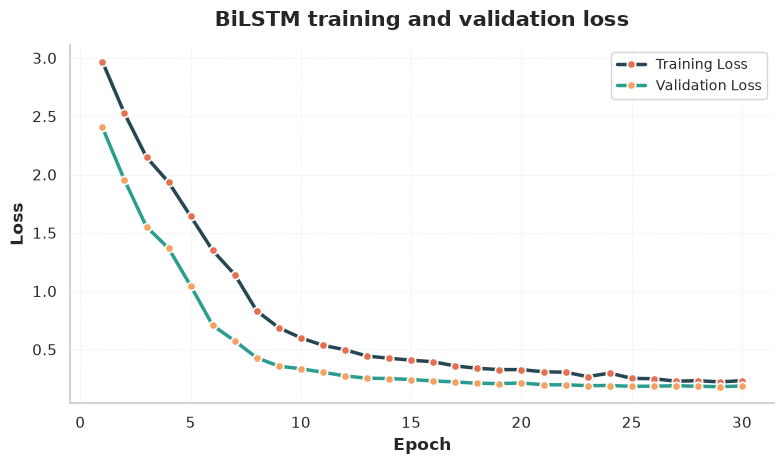

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4.8))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    color="#264653",              # deep teal/navy
    linewidth=2.5,
    marker="o",
    markersize=6,
    markerfacecolor="#E76F51",    # muted coral
    markeredgecolor="white",
    markeredgewidth=1.2,
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["eval_loss"],
    color="#2A9D8F",              # complementary teal
    linewidth=2.5,
    marker="o",
    markersize=6,
    markerfacecolor="#F4A261",    # muted orange
    markeredgecolor="white",
    markeredgewidth=1.2,
    label="Validation Loss"
)

plt.title(
    "BiLSTM training and validation loss",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel(
    "Epoch",
    fontsize=12,
    fontweight="semibold"
)

plt.ylabel(
    "Loss",
    fontsize=12,
    fontweight="semibold"
)

plt.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

plt.legend(
    frameon=True,
    fancybox=True,
    fontsize=10,
    loc="best"
)

sns.despine()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "plots" / "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Plot validation metric curves

Same curve names as the Transformer notebooks.

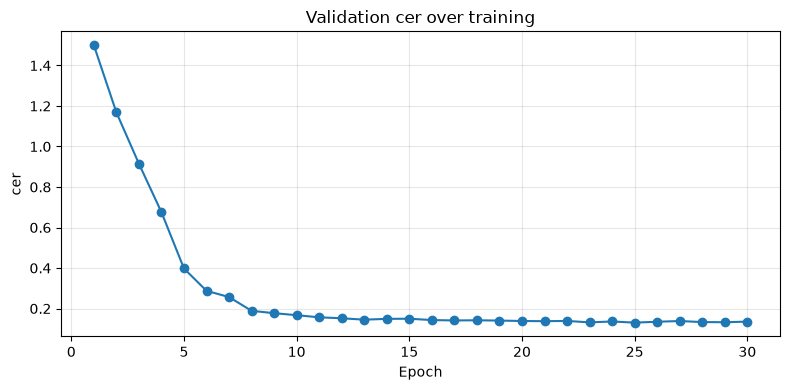

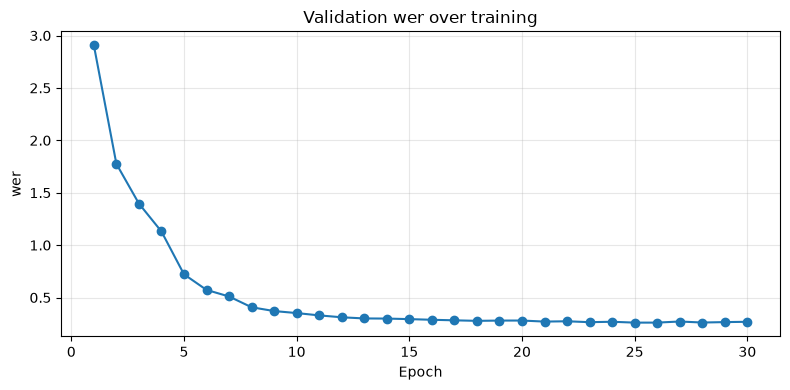

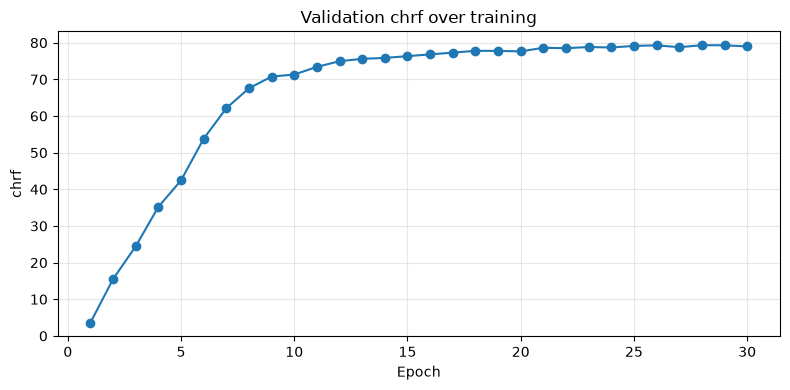

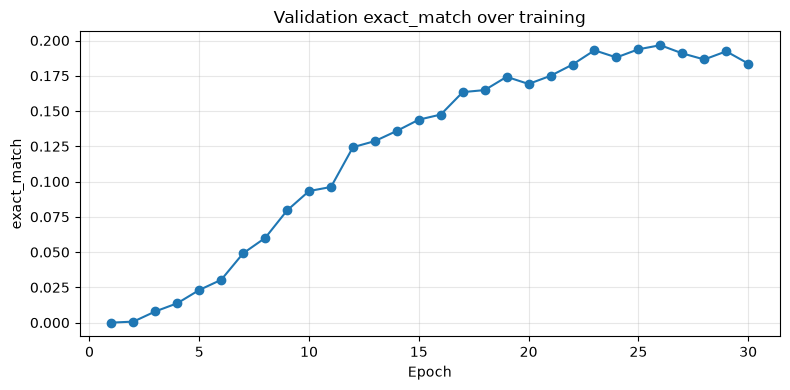

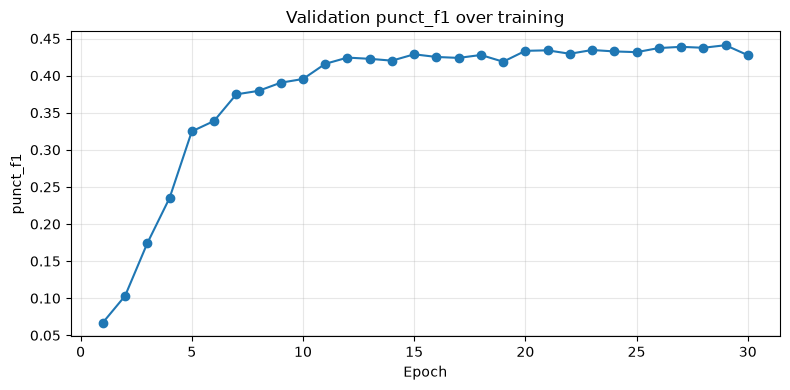

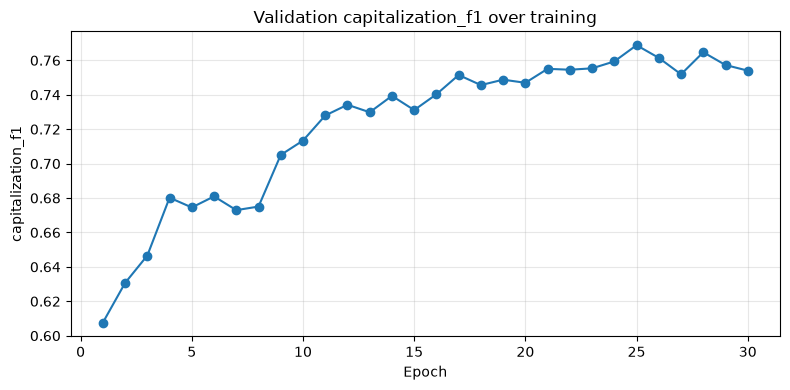

In [25]:
def plot_eval_metric(history_df: pd.DataFrame, metric_name: str):
    col = f"eval_{metric_name}"
    if col not in history_df.columns:
        print(f"Metric not found: {col}")
        return
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df[col], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(f"Validation {metric_name} over training")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plots" / f"validation_{metric_name}_curve.png", dpi=200)
    plt.show()

for metric in ["cer", "wer", "chrf", "exact_match", "punct_f1", "capitalization_f1"]:
    plot_eval_metric(history_df, metric)

## 21. Plot BiLSTM-specific gradient norm curve

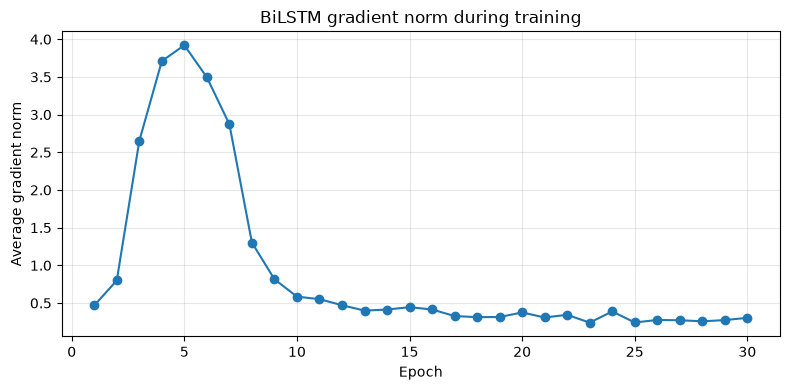

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["gradient_norm"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average gradient norm")
plt.title("BiLSTM gradient norm during training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "bilstm_gradient_norm_curve.png", dpi=200)
plt.show()

## 22. Final evaluation on train, validation, and test

The same metrics are used across train, validation, and test. This section runs after Section 18 has loaded and verified the best checkpoint.

In [27]:
train_predictions = generate_predictions_for_df(train_df, "train", sample_limit=EVAL_SAMPLE_LIMIT)
val_predictions = generate_predictions_for_df(val_df, "validation", sample_limit=EVAL_SAMPLE_LIMIT)
test_predictions = generate_predictions_for_df(test_df, "test", sample_limit=EVAL_SAMPLE_LIMIT)

metrics_train = evaluate_prediction_dataframe(train_predictions, "train")
metrics_val = evaluate_prediction_dataframe(val_predictions, "validation")
metrics_test = evaluate_prediction_dataframe(test_predictions, "test")

all_metrics = [metrics_train, metrics_val, metrics_test]
metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(OUTPUT_DIR / "all_split_metrics.csv", index=False, encoding="utf-8")
for name, metrics in [("train", metrics_train), ("validation", metrics_val), ("test", metrics_test)]:
    with open(OUTPUT_DIR / f"metrics_{name}.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
display(metrics_df)

Predict train:   0%|          | 0/173 [00:00<?, ?it/s]

{
  "split": "train",
  "num_sentences": 11064,
  "total_inference_seconds": 21.78702998161316,
  "average_inference_seconds_per_sentence": 0.001969182030153033,
  "sentences_per_second": 507.8250688293585
}


Predict validation:   0%|          | 0/22 [00:00<?, ?it/s]

{
  "split": "validation",
  "num_sentences": 1383,
  "total_inference_seconds": 2.73170804977417,
  "average_inference_seconds_per_sentence": 0.0019752046636111135,
  "sentences_per_second": 506.2766499203063
}


Predict test:   0%|          | 0/22 [00:00<?, ?it/s]

{
  "split": "test",
  "num_sentences": 1383,
  "total_inference_seconds": 2.7484428882598877,
  "average_inference_seconds_per_sentence": 0.0019873050529717194,
  "sentences_per_second": 503.1940106551074
}


,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,split,num_examples
0,0.112049,0.204490,83.894905,0.334960,0.733392,0.795439,0.504696,0.583999,0.625504,0.983387,0.838110,train,11064
1,0.132445,0.265615,79.306949,0.192336,0.635317,0.710281,0.361805,0.441027,0.584957,0.976643,0.757298,validation,1383
2,0.133357,0.260729,79.443592,0.203905,0.654901,0.677937,0.345939,0.427603,0.579205,0.978810,0.788286,test,1383


## 23. Save timing summary

In [28]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

timing_summary = {
    "training": training_time_info,
    "inference_train": load_json(OUTPUT_DIR / "inference_time_train.json"),
    "inference_validation": load_json(OUTPUT_DIR / "inference_time_validation.json"),
    "inference_test": load_json(OUTPUT_DIR / "inference_time_test.json"),
}
with open(OUTPUT_DIR / "timing_summary.json", "w", encoding="utf-8") as f:
    json.dump(timing_summary, f, indent=2, ensure_ascii=False)
print(json.dumps(timing_summary, indent=2))

{
  "training": {
    "training_start_time": "2026-08-04T12:42:07.950194",
    "training_end_time": "2026-08-04T13:14:56.516452",
    "training_seconds": 1968.566252231598,
    "training_minutes": 32.8094375371933,
    "training_hours": 0.5468239589532217,
    "best_epoch": 29,
    "best_val_loss": 0.17996734042059293,
    "peak_gpu_memory_gb": 16.600263118743896
  },
  "inference_train": {
    "split": "train",
    "num_sentences": 11064,
    "total_inference_seconds": 21.78702998161316,
    "average_inference_seconds_per_sentence": 0.001969182030153033,
    "sentences_per_second": 507.8250688293585
  },
  "inference_validation": {
    "split": "validation",
    "num_sentences": 1383,
    "total_inference_seconds": 2.73170804977417,
    "average_inference_seconds_per_sentence": 0.0019752046636111135,
    "sentences_per_second": 506.2766499203063
  },
  "inference_test": {
    "split": "test",
    "num_sentences": 1383,
    "total_inference_seconds": 2.7484428882598877,
    "average_in

## 24. Error category analysis

In [29]:
def has_punctuation_difference(pred: str, ref: str) -> bool:
    return get_punctuation_sequence(pred) != get_punctuation_sequence(ref)

def has_capitalization_difference(pred: str, ref: str) -> bool:
    return capitalization_labels(pred) != capitalization_labels(ref)

def has_spacing_difference(pred: str, ref: str) -> bool:
    return re.sub(r"\S", "X", pred) != re.sub(r"\S", "X", ref)

def classify_error(pred: str, ref: str) -> List[str]:
    if normalize_for_metric(pred) == normalize_for_metric(ref):
        return ["correct"]
    errors = []
    if has_punctuation_difference(pred, ref):
        errors.append("punctuation_error")
    if has_capitalization_difference(pred, ref):
        errors.append("capitalization_error")
    if has_spacing_difference(pred, ref):
        errors.append("spacing_error")
    if len(pred.split()) < len(ref.split()):
        errors.append("missing_word_error")
    if len(pred.split()) > len(ref.split()):
        errors.append("extra_word_error")
    if not errors:
        errors.append("orthographic_or_word_choice_error")
    return errors

def add_error_categories(pred_df: pd.DataFrame) -> pd.DataFrame:
    out = pred_df.copy()
    out["error_categories"] = [";".join(classify_error(p, r)) for p, r in zip(out["prediction"], out["target_text"])]
    return out

error_test_df = add_error_categories(test_predictions)
error_test_df.to_csv(OUTPUT_DIR / "analysis" / "test_error_categories.csv", index=False, encoding="utf-8")
error_counts = error_test_df["error_categories"].str.split(";").explode().value_counts().reset_index()
error_counts.columns = ["error_category", "count"]
error_counts.to_csv(OUTPUT_DIR / "analysis" / "test_error_category_counts.csv", index=False, encoding="utf-8")
display(error_counts)

,error_category,count
0,spacing_error,947
1,capitalization_error,845
2,punctuation_error,761
3,correct,282
4,missing_word_error,149
5,extra_word_error,110
6,orthographic_or_word_choice_error,47


## 25. Plot error categories

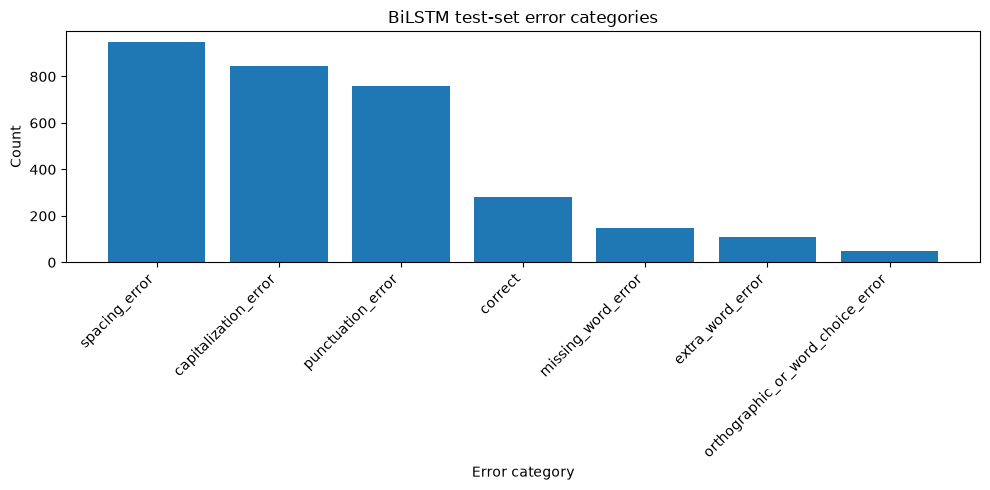

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(error_counts["error_category"], error_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Error category")
plt.ylabel("Count")
plt.title("BiLSTM test-set error categories")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "test_error_categories.png", dpi=200)
plt.show()

## 26. Best and worst predictions

In [31]:
best_predictions = error_test_df.sort_values(["sentence_cer", "sentence_wer"], ascending=True).head(20)
worst_predictions = error_test_df.sort_values(["sentence_cer", "sentence_wer"], ascending=False).head(20)
best_predictions.to_csv(OUTPUT_DIR / "analysis" / "top_20_best_predictions.csv", index=False, encoding="utf-8")
worst_predictions.to_csv(OUTPUT_DIR / "analysis" / "top_20_worst_predictions.csv", index=False, encoding="utf-8")
print("Best predictions")
display(best_predictions[["input_text", "target_text", "prediction", "sentence_cer", "sentence_wer", "error_categories"]])
print("Worst predictions")
display(worst_predictions[["input_text", "target_text", "prediction", "sentence_cer", "sentence_wer", "error_categories"]])

Best predictions


,input_text,target_text,prediction,sentence_cer,sentence_wer,error_categories
11,Meme Pas dans envelope?,Mem pas dans envelope?,Mem pas dans envelope?,0.0,0.0,correct
14,Tension boule viré.,Tension boule vire.,Tension boule vire.,0.0,0.0,correct
15,Li fer client fume bred mourom saaa,Li fer client fume bred mourom sa.,Li fer client fume bred mourom sa.,0.0,0.0,correct
20,Linn roder linn ggner.....,Linn rode linn gagne.....,Linn rode linn gagne.....,0.0,0.0,correct
23,Eski pou ena lekol demain????? Svp,Eski pu ena lekol demain????? Svp.,Eski pu ena lekol demain????? Svp.,0.0,0.0,correct
32,[NAME] einn?? Ki pou fer???,[NAME] ein?? Ki pu fer???,[NAME] ein?? Ki pu fer???,0.0,0.0,correct
33,Pren compte nu ban emergency food supply penda...,Pran compte nu bann emergency food supply pend...,Pran compte nu bann emergency food supply pend...,0.0,0.0,correct
34,Ki rôle mama la?,Ki rôle mama la?,Ki rôle mama la?,0.0,0.0,correct
38,Ena so cotée pervers ladan. Devek in fair kroi...,Ena so kote pervers ladan. Devek inn fer krwar...,Ena so kote pervers ladan. Devek inn fer krwar...,0.0,0.0,correct
44,9 ans apres? Tight. Scénario peut être monter ...,9 ans apre? Tight. Scénario peut être monte pi...,9 ans apre? Tight. Scénario peut être monte pi...,0.0,0.0,correct


Worst predictions


,input_text,target_text,prediction,sentence_cer,sentence_wer,error_categories
815,Nou envi kone [NAME] aster nou kapav dir si li...,Nu anvi kone [NAME] aster. Nu kapav dir si li ...,Nu anvi kone [NAME]. Aster nu kapav dir si li ...,2.453333,0.285714,capitalization_error;spacing_error
426,Misie minis al laba en casiet san journalis pa...,"Misye minis, ale laba en kasyet san journalis,...",Misye minis ale laba en kasyet san journalis p...,0.794590,0.859031,punctuation_error;capitalization_error;spacing...
967,𝑭𝒊𝒏𝒊 𝒕𝒊𝒓𝒆́ 𝒔𝒂 𝒏𝒐 𝒘𝒂𝒓𝒏𝒊𝒏𝒈 𝒛𝒕 𝒆𝒏𝒓𝒆𝒕𝒂𝒓𝒅🤣🤣🤣🤣,"𝑭𝒊𝒏𝒊 𝒕𝒊𝒓𝒆e 𝒔𝒂 𝒏𝒐 𝒘𝒂𝒓𝒏𝒊𝒏𝒈, 𝒛o𝒕 𝒆𝒏𝒓𝒆𝒕𝒂𝒓𝒅.🤣🤣🤣🤣",Ku kuki ku kuki kuki kum. 🤣🤣🤣🤣🤣🤣,0.790698,1.000000,punctuation_error;capitalization_error;spacing...
61,Kan la met 3 crédit pou hsc ça pas incite ban ...,Kan la met 3 crédit pu HSC sa pas incite bann ...,Kan la met 3 crédit pu HSC sa pas incite bann ...,0.720677,0.705882,punctuation_error;capitalization_error;spacing...
330,"[NAME], 'nou' kifer to pa al rode li alors si ...","[NAME], 'nu'? Kifer to pa ale rode li alors si...","[NAME], 'nu'' kifer to pa ale rode li. Alors s...",0.703297,0.774390,punctuation_error;capitalization_error;spacing...
911,Van la pe roule vite oui... Mais ene chauffeur...,Van la pe roule vite oui... Mais enn chauffeur...,Van la pe roule vite oui... Mais enn chauffeur...,0.675641,0.696552,punctuation_error;capitalization_error;spacing...
443,"Ene zafer mo pou dire, sa papier ki zot marké ...",Enn zafer mo pu dire: sa papier ki zot marke l...,"Enn zafer mo pu dire, sa papier ki zot marke l...",0.654646,0.727273,punctuation_error;capitalization_error;spacing...
549,"[NAME], ofait saki mne rode dir tou sa laloi p...","[NAME], ofet seki mon rode dir tu sa lalwa pe ...","[NAME], ofait seki mon rode dir tu sa laloi pe...",0.651064,0.673759,punctuation_error;capitalization_error;spacing...
1226,Mo pou dir enkor depi 2025 mo p dir misie anil...,"Mo pu dir ankor: depi 2025, mo pe dir misye An...","Mo pu dir ankor depi 2025, mo pe dir misie ani...",0.619414,0.706767,punctuation_error;capitalization_error;spacing...
418,Akz saem system la sant pa bn ki s docter s nu...,Akoz samem system la sante pa bon. Ki so docte...,Akoz samem system la sante pa bann ki so docte...,0.605263,0.713043,punctuation_error;capitalization_error;spacing...


## 27. Orthographic variation recovery analysis

Edit `ORTHOGRAPHIC_VARIANTS` with variants from your Mauritian Creole corpus.

In [32]:
ORTHOGRAPHIC_VARIANTS = {
    # "informal_variant": "target_standard_form"
    "mwa": "mo",
    "twa": "to",
    "kiii": "ki",
}

def variant_recovery_analysis(pred_df: pd.DataFrame, variants: Dict[str, str]) -> pd.DataFrame:
    rows = []
    for variant, target_form in variants.items():
        subset = pred_df[pred_df["input_text"].str.contains(rf"\b{re.escape(variant)}\b", case=False, regex=True, na=False)].copy()
        if subset.empty:
            rows.append({"variant": variant, "target_form": target_form, "num_cases": 0, "num_recovered": 0, "recovery_rate": None})
            continue
        recovered = subset["prediction"].str.contains(rf"\b{re.escape(target_form)}\b", case=False, regex=True, na=False)
        rows.append({"variant": variant, "target_form": target_form, "num_cases": int(len(subset)), "num_recovered": int(recovered.sum()), "recovery_rate": float(recovered.mean())})
    return pd.DataFrame(rows)

variant_df = variant_recovery_analysis(test_predictions, ORTHOGRAPHIC_VARIANTS)
variant_df.to_csv(OUTPUT_DIR / "analysis" / "orthographic_variant_recovery_test.csv", index=False, encoding="utf-8")
display(variant_df)

,variant,target_form,num_cases,num_recovered,recovery_rate
0,mwa,mo,3,3,1.0
1,twa,to,10,2,0.2
2,kiii,ki,0,0,NaN


## 28. Emoji and symbol subset analysis

In [33]:
EMOJI_SYMBOL_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+",
    flags=re.UNICODE,
)

def contains_emoji_or_symbol(text: str) -> bool:
    return bool(EMOJI_SYMBOL_PATTERN.search(str(text)))

def subset_metric_analysis(pred_df: pd.DataFrame, condition_col: str) -> pd.DataFrame:
    rows = []
    for value, subset in pred_df.groupby(condition_col):
        metrics = compute_text_metrics(subset["prediction"].tolist(), subset["target_text"].tolist())
        metrics[condition_col] = value
        metrics["num_examples"] = len(subset)
        rows.append(metrics)
    return pd.DataFrame(rows)

test_predictions_with_emoji = test_predictions.copy()
test_predictions_with_emoji["has_emoji_or_symbol"] = test_predictions_with_emoji["input_text"].apply(contains_emoji_or_symbol)
emoji_metrics_df = subset_metric_analysis(test_predictions_with_emoji, "has_emoji_or_symbol")
emoji_metrics_df.to_csv(OUTPUT_DIR / "analysis" / "emoji_symbol_subset_metrics_test.csv", index=False, encoding="utf-8")
display(emoji_metrics_df)

,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,has_emoji_or_symbol,num_examples
0,0.134790,0.261866,79.511983,0.211242,0.655591,0.682536,0.343478,0.428964,0.580395,0.978622,0.785276,False,1103
1,0.127249,0.255894,79.148402,0.175000,0.651970,0.515154,0.342930,0.402916,0.573951,0.979646,0.801299,True,280


## 29. Synthetic noise robustness analysis

This creates a controlled noisy test set. Use it as an additional robustness analysis, not as the main test-set result.

In [34]:
def add_repeated_letter_noise(text: str, probability: float = 0.08) -> str:
    out = []
    for ch in str(text):
        out.append(ch)
        if ch.isalpha() and random.random() < probability:
            out.append(ch * random.choice([1, 2]))
    return "".join(out)

def remove_random_punctuation(text: str, probability: float = 0.5) -> str:
    out = []
    for ch in str(text):
        if ch in PUNCTUATION_MARKS and random.random() < probability:
            continue
        out.append(ch)
    return "".join(out)

def create_noisy_test_set(df: pd.DataFrame) -> pd.DataFrame:
    noisy = df.copy()
    noisy[INPUT_COL] = noisy[INPUT_COL].apply(add_repeated_letter_noise).apply(remove_random_punctuation)
    return noisy

noisy_test_df = create_noisy_test_set(test_df)
noisy_test_df.to_csv(OUTPUT_DIR / "analysis" / "synthetic_noisy_test_inputs.csv", index=False, encoding="utf-8")
noisy_test_predictions = generate_predictions_for_df(noisy_test_df, "test_synthetic_noisy", sample_limit=EVAL_SAMPLE_LIMIT)
noisy_test_metrics = evaluate_prediction_dataframe(noisy_test_predictions, "test_synthetic_noisy")
with open(OUTPUT_DIR / "metrics_test_synthetic_noisy.json", "w", encoding="utf-8") as f:
    json.dump(noisy_test_metrics, f, indent=2, ensure_ascii=False)
display(pd.DataFrame([metrics_test, noisy_test_metrics]))

Predict test_synthetic_noisy:   0%|          | 0/22 [00:00<?, ?it/s]

{
  "split": "test_synthetic_noisy",
  "num_sentences": 1383,
  "total_inference_seconds": 2.7187697887420654,
  "average_inference_seconds_per_sentence": 0.001965849449560423,
  "sentences_per_second": 508.68595264179896
}


,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,split,num_examples
0,0.133357,0.260729,79.443592,0.203905,0.654901,0.677937,0.345939,0.427603,0.579205,0.978810,0.788286,test,1383
1,0.207121,0.437051,65.700058,0.033261,0.472693,0.501356,0.194995,0.257351,0.411342,0.963803,0.643678,test_synthetic_noisy,1383


## 30. Attention example visualization

This is BiLSTM-specific and optional. It visualizes how the decoder attends to input characters for one test example.

Input: Sofer simik ou ena pli boukou lalkol dn so disan so lizie flou li kwar li lor priorite pou li
Prediction: Sofer simik ou ena plis buku lalkol dan so disan so lizye folu li. Kwar li lor priorite pu li.


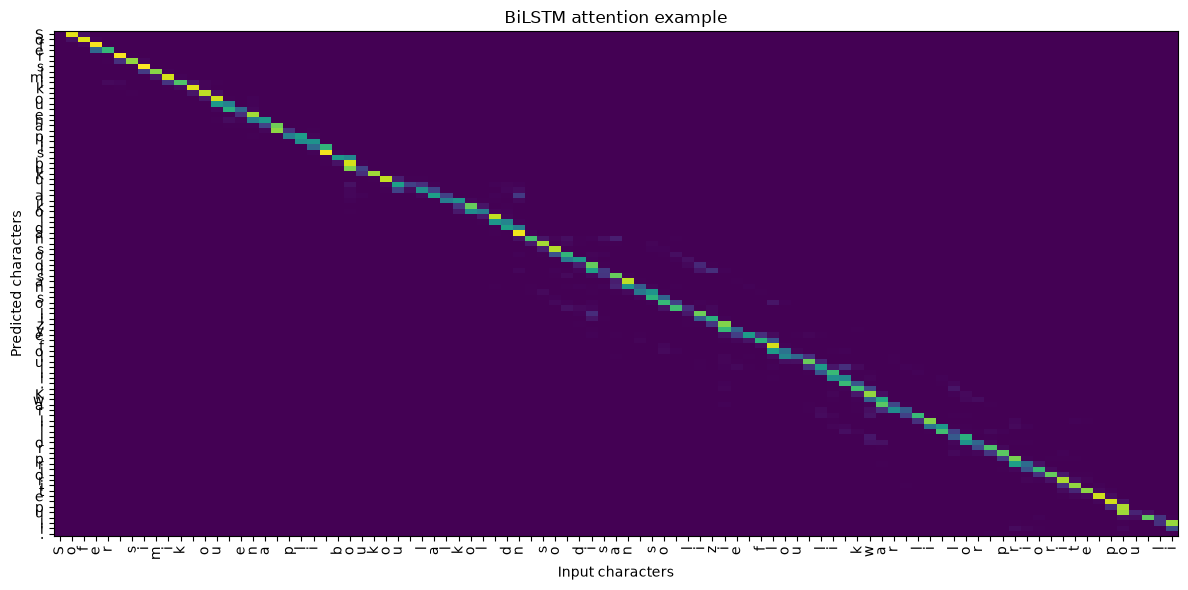

In [35]:
def get_attention_for_example(text: str):
    model.eval()
    src_ids = torch.tensor([encode_text(text, MAX_INPUT_LENGTH)], dtype=torch.long).to(DEVICE)
    src_lengths = torch.tensor([src_ids.size(1)], dtype=torch.long)
    with torch.no_grad():
        decoded_ids, attentions = model.greedy_decode(
            src=src_ids, src_lengths=src_lengths,
            max_len=MAX_TARGET_LENGTH, return_attention=True
        )
    pred = decode_ids(decoded_ids[0].cpu().tolist())
    src_chars = [itos.get(i, "") for i in src_ids[0].cpu().tolist() if i not in [PAD_IDX, SOS_IDX, EOS_IDX]]
    pred_chars = list(pred)
    if not attentions:
        return pred, src_chars, pred_chars, None
    attn_matrix = torch.stack([a[0] for a in attentions], dim=0).numpy()
    attn_matrix = attn_matrix[:len(pred_chars), :len(src_chars)]
    return pred, src_chars, pred_chars, attn_matrix

if len(test_df) > 0:
    sample_text = test_df.iloc[0][INPUT_COL]
    pred, src_chars, pred_chars, attn_matrix = get_attention_for_example(sample_text)
    print("Input:", sample_text)
    print("Prediction:", pred)
    if attn_matrix is not None and len(pred_chars) > 0 and len(src_chars) > 0:
        plt.figure(figsize=(12, 6))
        plt.imshow(attn_matrix, aspect="auto", cmap="viridis")
        plt.xticks(range(len(src_chars)), src_chars, rotation=90)
        plt.yticks(range(len(pred_chars)), pred_chars)
        plt.xlabel("Input characters")
        plt.ylabel("Predicted characters")
        plt.title("BiLSTM attention example")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "plots" / "bilstm_attention_example.png", dpi=200)
        plt.show()

## 31. Final BiLSTM experiment summary table

In [36]:
summary_rows = []
for metrics in all_metrics:
    row = metrics.copy()
    row["model"] = "BiLSTM"
    row["model_name"] = MODEL_NAME
    row["training_minutes"] = training_time_info["training_minutes"]
    row["peak_gpu_memory_gb"] = training_time_info["peak_gpu_memory_gb"]
    row["total_parameters"] = parameter_info["total_parameters"]
    row["trainable_parameters"] = parameter_info["trainable_parameters"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_cols = [
    "model", "model_name", "split", "num_examples", "cer", "wer", "chrf",
    "exact_match", "word_accuracy", "punct_f1", "capitalization_f1",
    "training_minutes", "peak_gpu_memory_gb", "total_parameters", "trainable_parameters"
]
summary_df = summary_df[[c for c in summary_cols if c in summary_df.columns]]
summary_df.to_csv(OUTPUT_DIR / "bilstm_experiment_summary.csv", index=False, encoding="utf-8")
display(summary_df)

,model,model_name,split,num_examples,cer,wer,chrf,exact_match,word_accuracy,punct_f1,capitalization_f1,training_minutes,peak_gpu_memory_gb,total_parameters,trainable_parameters
0,BiLSTM,char_bilstm_seq2seq_attention,train,11064,0.112049,0.204490,83.894905,0.334960,0.733392,0.583999,0.838110,32.809438,16.600263,2627597,2627597
1,BiLSTM,char_bilstm_seq2seq_attention,validation,1383,0.132445,0.265615,79.306949,0.192336,0.635317,0.441027,0.757298,32.809438,16.600263,2627597,2627597
2,BiLSTM,char_bilstm_seq2seq_attention,test,1383,0.133357,0.260729,79.443592,0.203905,0.654901,0.427603,0.788286,32.809438,16.600263,2627597,2627597


## 32. What each output is for

### Main model performance
- `all_split_metrics.csv`
- `bilstm_experiment_summary.csv`

### Runtime analysis
- `training_time.json`
- `timing_summary.json`

### Overfitting analysis
- `plots/loss_curve.png`
- `plots/validation_cer_curve.png`
- `plots/validation_wer_curve.png`
- `plots/validation_chrf_curve.png`

### BiLSTM-specific analysis
- `analysis/character_vocab.json`
- `analysis/bilstm_character_summary.csv`
- `analysis/bilstm_character_features_all_splits.csv`
- `analysis/bilstm_oov_character_analysis.json`
- `analysis/bilstm_parameter_count.json`
- `plots/bilstm_input_character_length_distribution.png`
- `plots/bilstm_gradient_norm_curve.png`
- `plots/bilstm_attention_example.png`

### Error analysis
- `analysis/test_error_category_counts.csv`
- `analysis/top_20_best_predictions.csv`
- `analysis/top_20_worst_predictions.csv`

### Orthographic variation analysis
- `analysis/orthographic_variant_recovery_test.csv`

### Emoji/noise analysis
- `analysis/emoji_symbol_subset_metrics_test.csv`
- `metrics_test_synthetic_noisy.json`

## 33. Notes for final comparison notebook

Later, the final comparison notebook can load:

```text
results/byt5/byt5_experiment_summary.csv
results/t5/t5_experiment_summary.csv
results/qwen/qwen_experiment_summary.csv
results/bilstm/bilstm_experiment_summary.csv
```

The comparison graphs can use the same metric columns:

- CER
- WER
- chrF
- Exact Match
- Word Accuracy
- Punctuation F1
- Capitalization F1
- Training time
- Inference time
- GPU memory

The BiLSTM-specific section can additionally discuss:

- Character vocabulary size
- OOV character rate
- Input/target character length distributions
- Padding/truncation behavior
- Parameter count
- Gradient norm stability
- Attention examples

## 34. References to discuss in the thesis

- PyTorch `torch.nn.LSTM` documentation for LSTM parameters and bidirectional behavior.
- PyTorch sequence-to-sequence tutorial for encoder-decoder and attention logic.
- Character-level sequence-to-sequence work for text normalization and orthographic transformation tasks.

Use your university's required citation style in the final thesis document.